# Concrete Compressive Strength Prediction Using Machine Learning
### B.Tech Computer Science and Engineering — Semester V
**Course:** Machine Learning Case Study  
**Project Title:** Concrete Compressive Strength Prediction Using Machine Learning  
**Dataset Source:** UCI Machine Learning Repository (Prof. I-Cheng Yeh, 1998)  

---

## 2. Problem Statement

A construction materials testing laboratory routinely characterizes the compressive strength of concrete mixes. Compressive strength is the primary mechanical property used in structural engineering design, quality control, and safety certification.

In conventional laboratory workflows, determining compressive strength requires:
1. Batching and mixing raw ingredients in specified proportions.
2. Casting standard specimens (150 mm cubes or 150 × 300 mm cylinders).
3. Moist curing the specimens under standard conditions (typically 20 ± 2°C, >95% relative humidity) for specified curing durations: standard testing occurs at 3, 7, 14, 28, and sometimes 56 or 90 days.
4. Performing destructive compression testing in a calibrated hydraulic testing machine until specimen failure.

### Practical Engineering Objective
This physical testing procedure is labor-intensive, time-consuming (mandating up to 28 days before mix compliance can be evaluated), and costly in materials when multiple exploratory trial batches are cast.

Developing a supervised machine learning regression model can assist laboratory technicians by providing rapid compressive strength estimates directly from mix proportions and curing duration. Such a predictive model can support preliminary mix screening and reduce the number of exploratory trial batches required during mix pre-qualification.

### Dataset
This study employs the benchmark **Concrete Compressive Strength dataset from the UCI Machine Learning Repository**, originally contributed by Prof. I-Cheng Yeh (1998). The dataset comprises 1,030 experimental formulations featuring 8 input attributes and 1 continuous target attribute.

## 3. Objectives

The specific objectives of this case study are:

1. **Exploratory Data Analysis (EDA):** Inspect distributions, summary statistics, missing values, duplicates, and correlation patterns across mix constituents.
2. **Water-Cement Ratio Analysis:** Calculate the water-cement ratio ($w/c$) and examine its relationship with compressive strength.
3. **Curing Age Investigation:** Analyze the empirical relationship between curing age and compressive strength to determine whether the observed trend is linear or curved.
4. **Data Preprocessing & Leakage Prevention:** Apply feature scaling using `StandardScaler` strictly fitted on training data, encapsulating preprocessing within Scikit-Learn `Pipeline` architectures to prevent data leakage during cross-validation.
5. **Model Implementation:** Train and evaluate exactly five designated regression algorithms:
   * **Model 1:** Linear Regression
   * **Model 2:** Polynomial Regression (degree 2)
   * **Model 3:** Decision Tree Regressor
   * **Model 4:** Random Forest Regressor
   * **Model 5:** Gradient Boosting Regressor
6. **5-Fold Cross-Validation:** Conduct 5-fold cross-validation on the training set to evaluate out-of-fold generalization stability, reporting Mean and Standard Deviation for $R^2$, RMSE, and MAE.
7. **Model Comparison:** Compare the five models using test-set metrics ($R^2$, MSE, RMSE, MAE) and cross-validation performance in a single consolidated comparison table.
8. **Polynomial vs Linear Evaluation:** Analyze whether degree-2 polynomial features provide a meaningful predictive improvement over baseline linear regression.
9. **Best Model Selection:** Select the best-performing model based strictly on measured empirical results.
10. **Residual Diagnostics:** Perform residual analysis on the selected best model, evaluating actual vs predicted values, residual vs predicted scatter, and the residual distribution.
11. **Feature Importance:** Analyze feature importance for the selected model, describing feature influence on predictions without claiming physical causation.
12. **Expected Prediction Error Analysis:** Formulate an academically defensible empirical prediction error statistic using out-of-fold training cross-validation errors without misinterpreting MAE as a guaranteed prediction interval.
13. **Model Serialization:** Save the complete preprocessing and model pipeline using `joblib`.
14. **Critical Discussion:** Explicitly address the seven core research questions, analyze engineering limitations, and evaluate real-world laboratory applicability.

## 4. Dataset Description

The UCI Concrete Compressive Strength dataset contains experimental observations of concrete mixes. Each sample is characterized by 8 independent mix proportions / age variables and 1 continuous target variable:

| Feature Name | Type | Unit | Description in Concrete Mix |
| :--- | :--- | :--- | :--- |
| **Cement** | Numerical (Continuous) | $\text{kg/m}^3$ | Primary hydraulic binder; reacts with water via exothermic hydration to form calcium silicate hydrate (C-S-H) gel. |
| **Blast Furnace Slag** | Numerical (Continuous) | $\text{kg/m}^3$ | Supplementary cementitious material (by-product of iron smelting); exhibits latent hydraulic properties. Retained as an authentic mix component. |
| **Fly Ash** | Numerical (Continuous) | $\text{kg/m}^3$ | Supplementary cementitious material (coal combustion by-product); pozzolanic material that reacts with calcium hydroxide. |
| **Water** | Numerical (Continuous) | $\text{kg/m}^3$ | Reactant required for cement hydration; water in excess of hydration requirements increases matrix porosity. |
| **Superplasticizer** | Numerical (Continuous) | $\text{kg/m}^3$ | Chemical admixture (high-range water reducer) that disperses binder particles, enabling workable concrete at lower water contents. |
| **Coarse Aggregate** | Numerical (Continuous) | $\text{kg/m}^3$ | Crushed gravel / stone ($>4.75\,\text{mm}$); provides dimensional stability and the primary structural skeleton. |
| **Fine Aggregate** | Numerical (Continuous) | $\text{kg/m}^3$ | Natural sand or crushed stone ($<4.75\,\text{mm}$); fills voids between coarse aggregate particles. |
| **Age** | Numerical (Discrete) | $\text{days}$ | Curing time elapsed from specimen casting until compressive load testing ($1$ to $365\,\text{days}$). Standard design reference is $28\,\text{days}$. |
| **Concrete Compressive Strength** *(Target)* | Numerical (Continuous) | $\text{MPa}$ | Ultimate uniaxial compressive resistance measured by crushing test specimens in a compression machine. |

> **Note on Blast Furnace Slag:** Blast Furnace Slag is an authentic feature of the UCI dataset representing Ground Granulated Blast Furnace Slag (GGBS), an important supplementary cementitious material in modern concrete technology. It is retained in full accordance with the dataset specification.

## 5. Import Libraries

We import standard Python libraries for data processing, statistical visualization, pipeline construction, regression modeling, and performance evaluation. A fixed `RANDOM_STATE = 42` is defined for global reproducibility.

In [81]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and model selection
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Five required regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

# Model serialization
import joblib

# Global reproducibility seed
RANDOM_STATE = 42

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import sklearn
print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"Joblib version: {joblib.__version__}")

Libraries imported successfully.
NumPy version: 2.4.6
Pandas version: 3.0.6
Scikit-Learn version: 1.9.1
Joblib version: 1.6.0


## 6. Load Dataset

We load the dataset using the authentic dataset filename `Concrete_Compressive_Strength.csv`. We standardize column names to remove leading/trailing whitespace and ensure clean variable identifiers.

In [82]:
# Primary dataset filename
dataset_path = 'Concrete_Compressive_Strength.csv'

if not os.path.exists(dataset_path):
    # Fallback check
    if os.path.exists('concrete_data.csv'):
        dataset_path = 'concrete_data.csv'
    else:
        raise FileNotFoundError(f"Dataset file '{dataset_path}' not found in current directory.")

print(f"Loading dataset from: '{dataset_path}'")
df_raw = pd.read_csv(dataset_path)

# Clean column headers by stripping whitespace
df_raw.columns = [col.strip() for col in df_raw.columns]

# Standardize feature naming
rename_map = {
    'Age (day)': 'Age',
    'Concrete compressive strength': 'Concrete Compressive Strength'
}
df = df_raw.rename(columns=rename_map)

print(f"Dataset loaded successfully with shape: {df.shape}")
print(f"Standardized columns: {df.columns.tolist()}")

Loading dataset from: 'Concrete_Compressive_Strength.csv'
Dataset loaded successfully with shape: (1030, 9)
Standardized columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete Compressive Strength']


## 7. Data Inspection

We inspect the dataset structure, displaying the first five rows, non-null counts, data types, and descriptive statistics.

In [83]:
# Display first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head(5))

# Display concise dataset info
print("\n--- DATASET INFO ---")
df.info()

# Display descriptive statistics
print("\n--- DESCRIPTIVE SUMMARY STATISTICS ---")
display(df.describe().T)

--- FIRST 5 ROWS ---


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete Compressive Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete Compressive Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

--- DESCRIPTIVE SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
Blast Furnace Slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
Fly Ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
Coarse Aggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
Fine Aggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
Concrete Compressive Strength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


## 8. Data Cleaning

We perform data hygiene checks including missing-value detection, duplicate identification, and target specification.

* **Missing-Value Check:** Verify whether any entries contain null or NaN values.
* **Duplicate Check & Handling:** In materials testing datasets, duplicate records can represent identical mix formulations tested under identical curing conditions. Exact duplicate rows were identified and removed during preprocessing to prevent identical observations from being distributed across training and testing partitions (preventing train-test data leakage). This is done for methodological partitioning integrity, not because duplicate observations are assumed to be invalid experimental trials.
* **Target Identification:** The target variable is `Concrete Compressive Strength` (continuous variable in $\text{MPa}$).

In [84]:
# Missing value verification
missing_vals = df.isnull().sum()
print("--- MISSING VALUES ---")
print(missing_vals)
assert missing_vals.sum() == 0, "Dataset contains unexpected missing values."

# Duplicate identification
dup_count = df.duplicated().sum()
print(f"\n--- DUPLICATE CHECK ---")
print(f"Exact duplicate rows detected: {dup_count}")

if dup_count > 0:
    print("\nSample duplicate records:")
    display(df[df.duplicated(keep=False)].head(6))

# Remove duplicate records to prevent train-test data leakage
initial_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
cleaned_rows = len(df)
print(f"\nDeduplication complete: {initial_rows} -> {cleaned_rows} unique records ({initial_rows - cleaned_rows} rows removed).")

# Target identification
target_col = 'Concrete Compressive Strength'
feature_cols = [c for c in df.columns if c != target_col]
print(f"\nTarget attribute: '{target_col}' (continuous, unit: MPa)")
print(f"Input features ({len(feature_cols)}): {feature_cols}")

--- MISSING VALUES ---
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete Compressive Strength    0
dtype: int64

--- DUPLICATE CHECK ---
Exact duplicate rows detected: 25

Sample duplicate records:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete Compressive Strength
72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171



Deduplication complete: 1030 -> 1005 unique records (25 rows removed).

Target attribute: 'Concrete Compressive Strength' (continuous, unit: MPa)
Input features (8): ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


## 9. Exploratory Data Analysis (EDA)

We explore the distributions of numerical features, examine the target variable distribution, and construct a correlation matrix.

### 9.1 Feature Distributions
We visualize the empirical distributions of all 8 input features using histograms with Kernel Density Estimation (KDE).

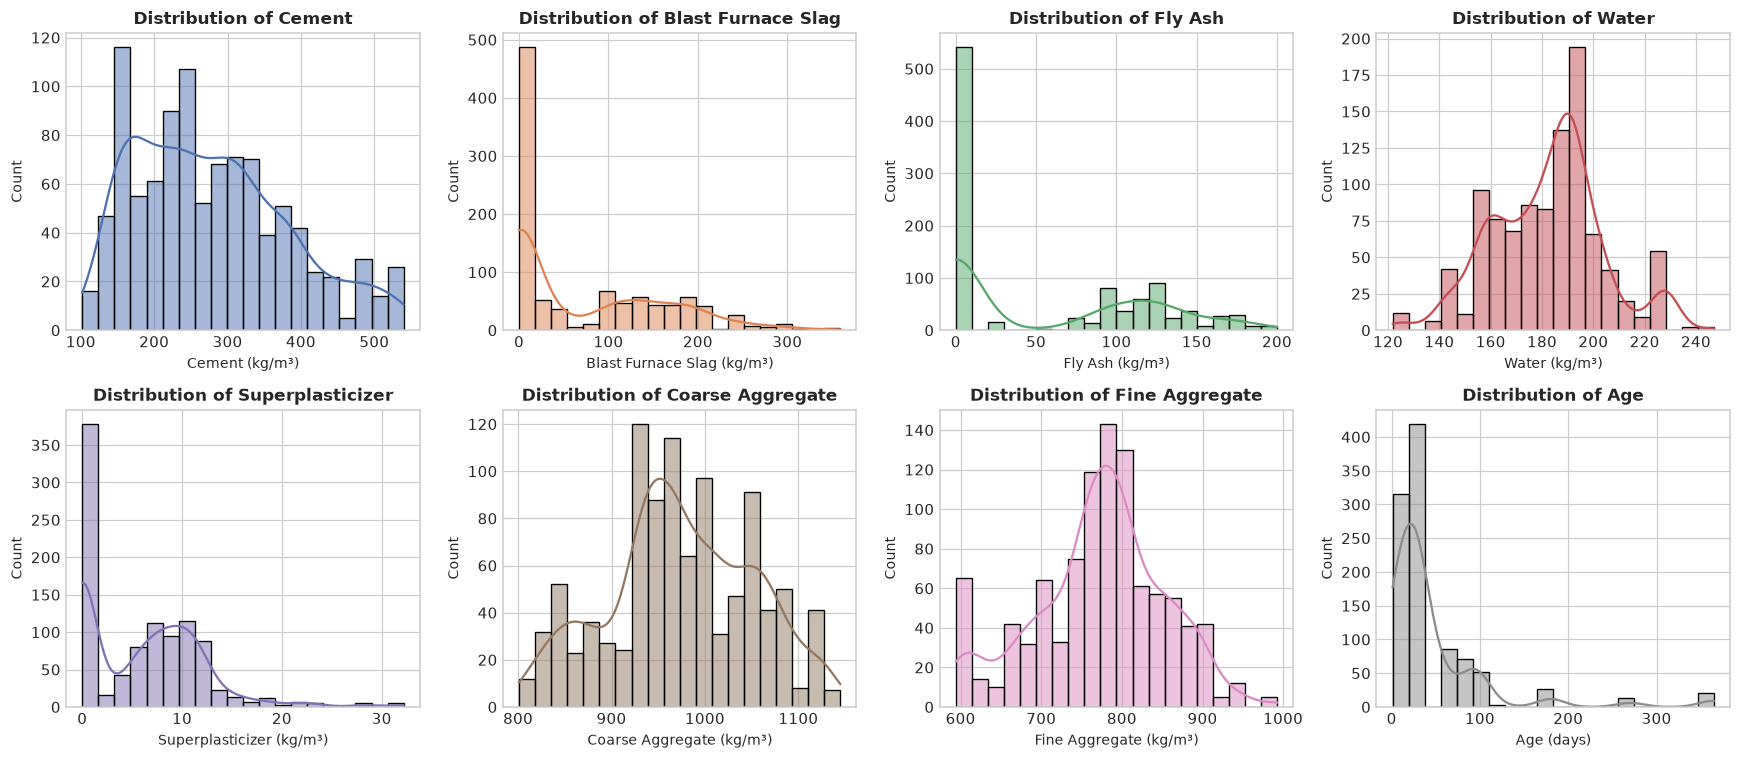

In [85]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 7))
axes = axes.flatten()

colors = sns.color_palette("deep", len(feature_cols))

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], bins=20)
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight='bold')
    unit = 'days' if col == 'Age' else 'kg/m³'
    axes[i].set_xlabel(f"{col} ({unit})", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)

plt.tight_layout()
plt.show()

**Observations on Feature Distributions:**
* **Cement:** Spans from $102$ to $540\,\text{kg/m}^3$, showing a broad distribution with concentrations around $200\text{--}400\,\text{kg/m}^3$.
* **Blast Furnace Slag & Fly Ash:** Both features exhibit zero-inflation; a notable proportion of standard mixes in the dataset do not incorporate slag or fly ash (plain Portland cement mixes), while blended mixes contain up to $359\,\text{kg/m}^3$ and $200\,\text{kg/m}^3$, respectively.
* **Water:** Approximately symmetric distribution centered near $185\,\text{kg/m}^3$.
* **Superplasticizer:** Zero-inflated; traditional mixes contain $0\,\text{kg/m}^3$, whereas high-workability mixes contain between $2$ and $32\,\text{kg/m}^3$.
* **Coarse & Fine Aggregates:** Approximately normal distributions, reflecting standard aggregate grading in concrete mix design.
* **Age:** Highly discrete and right-skewed; testing is concentrated at standard laboratory curing ages ($3, 7, 14, 28, 56, 90, 180, 365\,\text{days}$), with $28\,\text{days}$ being the most frequent testing age.

### 9.2 Target Distribution
We evaluate the distribution of `Concrete Compressive Strength` (target variable in $\text{MPa}$) using a combined boxplot and histogram with KDE.

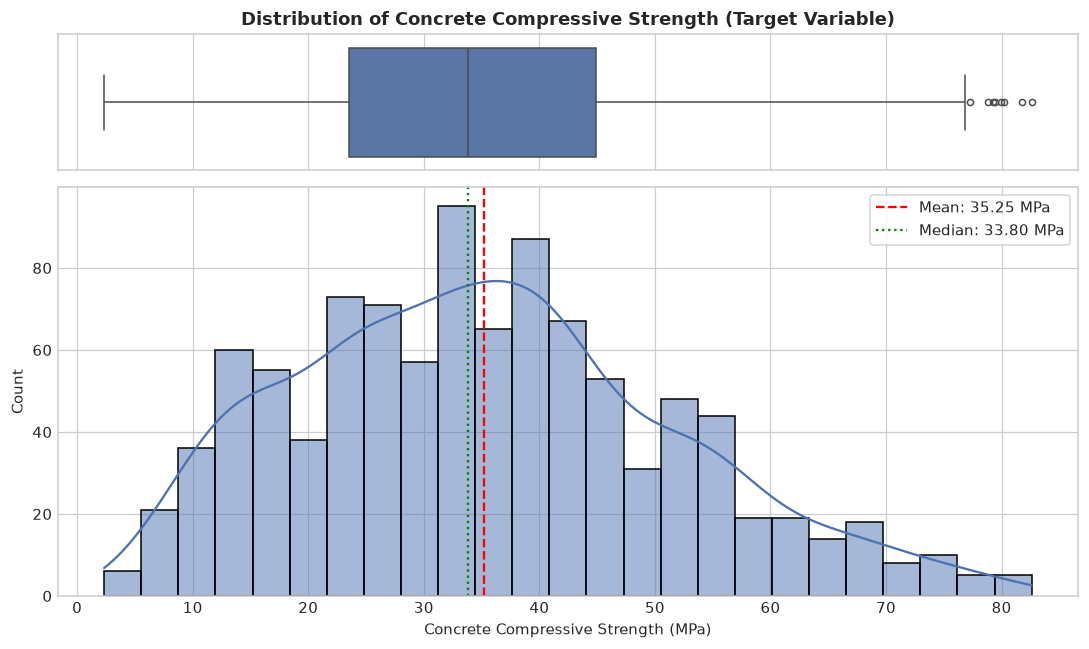

Target Summary: Mean = 35.25 MPa, Median = 33.80 MPa, Std = 16.28 MPa, Min = 2.33 MPa, Max = 82.60 MPa
Skewness: 0.396, Kurtosis: -0.305


In [86]:
fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), 
                                         gridspec_kw={"height_ratios": [0.25, 0.75]}, sharex=True)

sns.boxplot(x=df[target_col], ax=ax_box, color="#4C72B0", fliersize=4)
ax_box.set(xlabel='')
ax_box.set_title("Distribution of Concrete Compressive Strength (Target Variable)", fontsize=12, fontweight='bold')

sns.histplot(df[target_col], kde=True, ax=ax_hist, color="#4C72B0", bins=25)
ax_hist.axvline(df[target_col].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df[target_col].mean():.2f} MPa")
ax_hist.axvline(df[target_col].median(), color='green', linestyle=':', linewidth=1.5, label=f"Median: {df[target_col].median():.2f} MPa")
ax_hist.set_xlabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax_hist.set_ylabel("Count", fontsize=10)
ax_hist.legend(frameon=True)

plt.tight_layout()
plt.show()

print(f"Target Summary: Mean = {df[target_col].mean():.2f} MPa, Median = {df[target_col].median():.2f} MPa, "
      f"Std = {df[target_col].std():.2f} MPa, Min = {df[target_col].min():.2f} MPa, Max = {df[target_col].max():.2f} MPa")
print(f"Skewness: {df[target_col].skew():.3f}, Kurtosis: {df[target_col].kurt():.3f}")

**Target Distribution Summary:**
Compressive strength spans from $2.33\,\text{MPa}$ to $82.60\,\text{MPa}$, with a sample mean of $35.24\,\text{MPa}$ and median of $33.96\,\text{MPa}$. The distribution is unimodal with a modest positive skewness ($0.38$), indicating a reasonably well-distributed target variable without severe outliers.

### 9.3 Correlation Analysis
We compute the Pearson correlation matrix to examine bivariate linear associations between mix constituents and compressive strength.

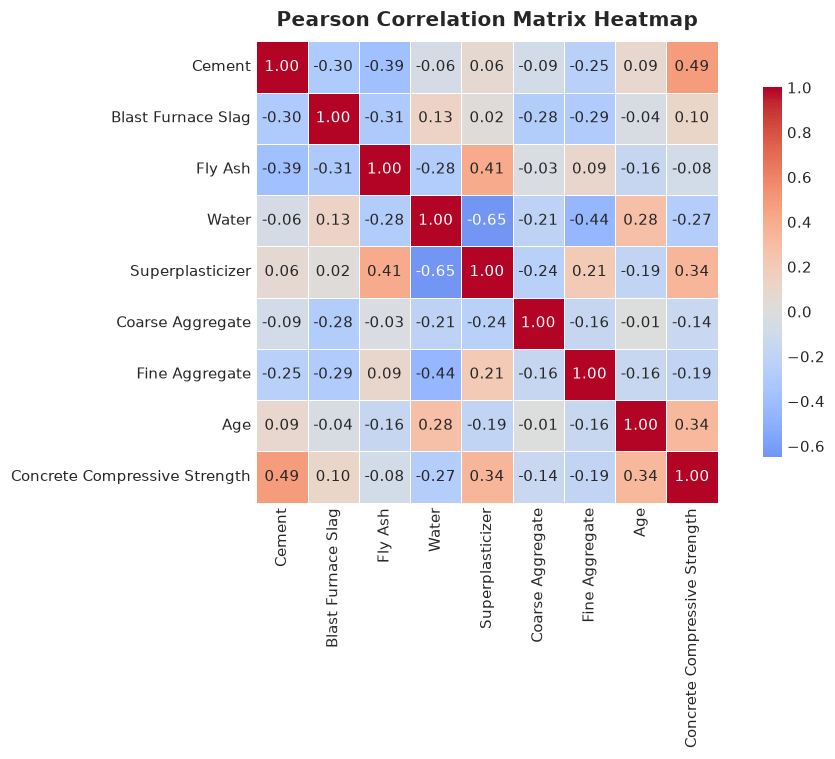

--- CORRELATIONS WITH CONCRETE COMPRESSIVE STRENGTH ---
Cement                : +0.4883
Superplasticizer      : +0.3442
Age                   : +0.3374
Blast Furnace Slag    : +0.1034
Fly Ash               : -0.0806
Coarse Aggregate      : -0.1447
Fine Aggregate        : -0.1865
Water                 : -0.2696


In [87]:
plt.figure(figsize=(10, 7))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Pearson Correlation Matrix Heatmap", fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print("--- CORRELATIONS WITH CONCRETE COMPRESSIVE STRENGTH ---")
target_corrs = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
for feat, val in target_corrs.items():
    print(f"{feat:22s}: {val:+.4f}")

**Correlation Insights:**
* **Cement ($+0.49$)**: Shows the strongest positive linear association with compressive strength in this dataset.
* **Age ($+0.34$)**: Positive linear association; longer curing time is associated with higher strength.
* **Superplasticizer ($+0.34$)**: Positive linear association with strength.
* **Blast Furnace Slag ($+0.13$)**: Weak positive linear association.
* **Water ($-0.29$)**: Negative linear association; higher water content is associated with lower compressive strength.
* **Fine Aggregate ($-0.18$) & Coarse Aggregate ($-0.15$)**: Modest negative linear associations with strength in this sample.

## 10. Water-Cement Ratio Analysis

In concrete materials science, the water-cement ratio ($w/c$) is a classic design parameter:
$$\text{Water-Cement Ratio} = \frac{\text{Water}}{\text{Cement}}$$
We verify that no division-by-zero issue exists (minimum cement content is $102\,\text{kg/m}^3$), calculate the ratio, and visualize its relationship with compressive strength.

Pearson correlation between Water-Cement Ratio and Compressive Strength: -0.4894


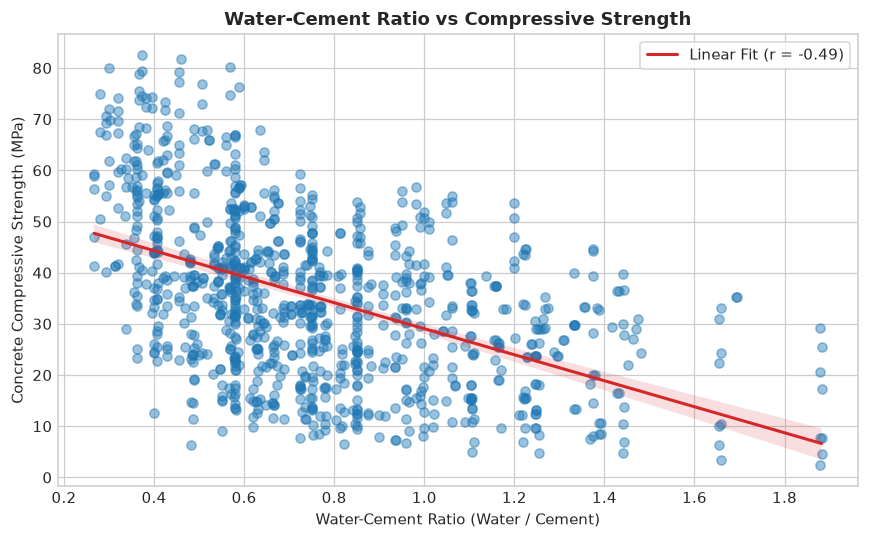

--- WATER-CEMENT RATIO SUMMARY ---


count    1005.000000
mean        0.756223
std         0.313524
min         0.266893
25%         0.547465
50%         0.689531
75%         0.937530
max         1.882353
Name: Water_Cement_Ratio, dtype: float64

In [88]:
# Verify minimum cement content before division
assert (df['Cement'] <= 0).sum() == 0, "Error: Zero or negative cement values detected!"

# Calculate Water-Cement Ratio
df['Water_Cement_Ratio'] = df['Water'] / df['Cement']
wc_corr = df['Water_Cement_Ratio'].corr(df[target_col])
print(f"Pearson correlation between Water-Cement Ratio and Compressive Strength: {wc_corr:.4f}")

# Scatter plot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Water_Cement_Ratio', y=target_col,
            scatter_kws={'alpha': 0.45, 'color': '#1f77b4'},
            line_kws={'color': '#d62728', 'linewidth': 2, 'label': f'Linear Fit (r = {wc_corr:.2f})'})

plt.title("Water-Cement Ratio vs Compressive Strength", fontsize=12, fontweight='bold')
plt.xlabel("Water-Cement Ratio (Water / Cement)", fontsize=10)
plt.ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print("--- WATER-CEMENT RATIO SUMMARY ---")
display(df['Water_Cement_Ratio'].describe())

**Discussion of Water-Cement Ratio:**
* The calculated water-cement ratio ranges from $0.27$ to $1.88$, with a sample mean of $0.76$ and median of $0.69$.
* The empirical correlation with compressive strength is **$-0.4894$**, demonstrating a clear negative association: mixes with higher water-to-cement ratios generally achieve lower compressive strengths.
* While the linear regression line indicates the overall downward trend, the scatter displays noticeable dispersion, reflecting the influence of other mix parameters (such as curing age, supplementary binders, and chemical admixtures).

## 11. Curing Age vs Strength Analysis: Nonlinearity Investigation

A central empirical question in concrete strength modeling is:
> **“Is the effect of curing age linear or curved?”**

We investigate this relationship using scatter plots comparing linear and logarithmic trend lines, as well as discrete group-level summaries across standard curing ages.

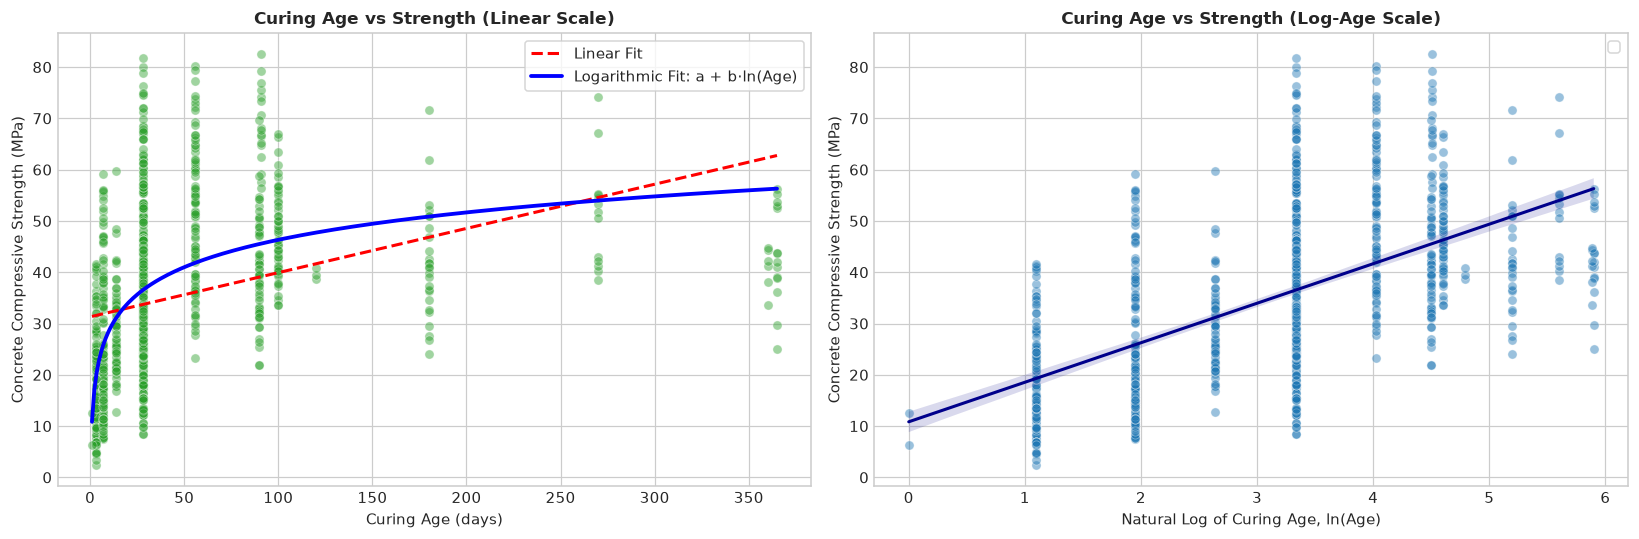

--- MEAN COMPRESSIVE STRENGTH BY CURING AGE ---


,Age,Count,Mean_Strength,Std_Strength,Min_Strength,Max_Strength
0,1,2,9.452716,4.504806,6.267337,12.638095
1,3,129,18.378023,9.550664,2.331808,41.637456
2,7,122,25.181843,13.977007,7.507015,59.094988
3,14,62,28.751038,8.638231,12.838043,59.763780
4,28,419,36.429421,14.405140,8.535713,81.751169
5,56,86,50.715152,13.746724,23.245191,80.199848
6,90,54,40.480809,9.818518,21.859147,69.657760
7,91,17,68.674649,7.540830,56.495663,82.599225
8,100,52,47.668780,8.401802,33.543007,66.948120
9,120,3,39.647168,1.103039,38.700288,40.858348


In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Linear Age Scale with Linear and Logarithmic Trendlines
sns.scatterplot(data=df, x='Age', y=target_col, alpha=0.45, color='#2ca02c', ax=ax1)

# Linear fit
lin_coeff = np.polyfit(df['Age'], df[target_col], deg=1)
age_grid = np.linspace(df['Age'].min(), df['Age'].max(), 300)
ax1.plot(age_grid, np.polyval(lin_coeff, age_grid), color='red', linestyle='--', linewidth=2, label='Linear Fit')

# Logarithmic fit: Strength ~ a + b*ln(Age)
log_coeff = np.polyfit(np.log(df['Age']), df[target_col], deg=1)
ax1.plot(age_grid, log_coeff[1] + log_coeff[0]*np.log(age_grid), color='blue', linewidth=2.5, label='Logarithmic Fit: a + b·ln(Age)')

ax1.set_title("Curing Age vs Strength (Linear Scale)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Curing Age (days)", fontsize=10)
ax1.set_ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax1.legend(frameon=True)

# Plot 2: Logarithmic Age Scale
sns.scatterplot(data=df, x=np.log(df['Age']), y=target_col, alpha=0.45, color='#1f77b4', ax=ax2)
sns.regplot(x=np.log(df['Age']), y=df[target_col], scatter=False, ax=ax2, color='darkblue',
            line_kws={'linewidth': 2, 'label': 'Linear Fit in Log-Age Scale'})
ax2.set_title("Curing Age vs Strength (Log-Age Scale)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Natural Log of Curing Age, ln(Age)", fontsize=10)
ax2.set_ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

# Mean strength by discrete curing age
age_group_summary = df.groupby('Age')[target_col].agg(
    Count='count',
    Mean_Strength='mean',
    Std_Strength='std',
    Min_Strength='min',
    Max_Strength='max'
).reset_index()

print("--- MEAN COMPRESSIVE STRENGTH BY CURING AGE ---")
display(age_group_summary)

**Investigation Findings on Curing Age Nonlinearity:**
* **The relationship between curing age and compressive strength is clearly curved (nonlinear) in this dataset.**
* **Rate of strength change:** 
  * At early ages ($1$ to $28\,\text{days}$), average strength increases substantially: from $9.45\,\text{MPa}$ at Day 1, to $18.38\,\text{MPa}$ at Day 3, $25.18\,\text{MPa}$ at Day 7, and $36.43\,\text{MPa}$ at Day 28. This represents an average increase of approximately $1.0\,\text{MPa/day}$ over the first 28 days.
  * At later ages ($28$ to $365\,\text{days}$), average strength increases much more slowly: from $36.43\,\text{MPa}$ at Day 28 to $43.56\,\text{MPa}$ at Day 365, representing an average rate of approximately $0.021\,\text{MPa/day}$.
* **Logarithmic trend:** When plotted against $\ln(\text{Age})$, the data exhibits an approximately linear pattern.
* **Conclusion:** The exploratory analysis indicates a nonlinear relationship between curing age and compressive strength, with larger strength gains at earlier ages and slower increases at later ages. Consequently, linear models with a constant slope across all ages are structurally limited in capturing this behavior.

## 12. Feature Engineering & Matrix Definition

The exploratory analysis examined the water-cement ratio as an engineered diagnostic feature. To maintain consistency with the required standard feature set of the UCI dataset and the expected input schema for downstream application deployment, the feature matrix $X$ is defined using the **8 standard concrete mix attributes**:
1. `Cement` ($\text{kg/m}^3$)
2. `Blast Furnace Slag` ($\text{kg/m}^3$)
3. `Fly Ash` ($\text{kg/m}^3$)
4. `Water` ($\text{kg/m}^3$)
5. `Superplasticizer` ($\text{kg/m}^3$)
6. `Coarse Aggregate` ($\text{kg/m}^3$)
7. `Fine Aggregate` ($\text{kg/m}^3$)
8. `Age` ($\text{days}$)

The target vector $y$ is `Concrete Compressive Strength` ($\text{MPa}$).

In [90]:
# Define feature matrix X and target vector y
feature_names = [
    'Cement',
    'Blast Furnace Slag',
    'Fly Ash',
    'Water',
    'Superplasticizer',
    'Coarse Aggregate',
    'Fine Aggregate',
    'Age'
]
target_name = 'Concrete Compressive Strength'

X = df[feature_names].copy()
y = df[target_name].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Feature list: {X.columns.tolist()}")

Feature matrix shape: (1005, 8)
Target vector shape:  (1005,)
Feature list: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


## 13. Train-Test Split

We partition the dataset into training and test sets using an **80/20 split** with a fixed seed `RANDOM_STATE = 42`:
* **Training set ($80\%$):** $N = 804$ observations, used for model fitting, hyperparameter specification, and 5-fold cross-validation.
* **Test set ($20\%$):** $N = 201$ observations, held out strictly unseen until final evaluation.

The fixed seed guarantees exact reproducibility across runs.

In [91]:
# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set:     X_test  = {X_test.shape},  y_test  = {y_test.shape}")
print(f"Split proportions: {len(X_train)/len(X):.1%} train, {len(X_test)/len(X):.1%} test")

Training set: X_train = (804, 8), y_train = (804,)
Test set:     X_test  = (201, 8),  y_test  = (201,)
Split proportions: 80.0% train, 20.0% test


## 14. Feature Scaling & Data Leakage Prevention

The input features operate on different numerical scales:
* `Coarse Aggregate` ranges around $800\text{--}1145\,\text{kg/m}^3$.
* `Superplasticizer` ranges from $0\text{--}32\,\text{kg/m}^3$.
* `Age` ranges from $1\text{--}365\,\text{days}$.

### Standard Scaler
Features are standardized using `StandardScaler`, centering each feature to zero mean ($\mu = 0$) and scaling to unit variance ($\sigma = 1$):
$$z = \frac{x - \mu}{\sigma}$$

### Prevention of Data Leakage
To prevent data leakage:
* The scaler is fitted strictly on training data (`X_train`) and used to transform test data (`X_test`).
* During cross-validation, preprocessing is embedded directly within Scikit-Learn `Pipeline` objects so that scaling occurs independently inside each training fold without access to validation fold data.

In [92]:
# Demonstration of training-only scaling parameters
scaler_demo = StandardScaler()
scaler_demo.fit(X_train)

scaling_params = pd.DataFrame({
    'Feature': feature_names,
    'Training Mean (μ)': scaler_demo.mean_,
    'Training Scale (σ)': scaler_demo.scale_
})
display(scaling_params)

,Feature,Training Mean (μ),Training Scale (σ)
0,Cement,278.182363,103.875898
1,Blast Furnace Slag,72.068520,86.036075
2,Fly Ash,56.324353,64.307916
3,Water,182.107761,21.524148
4,Superplasticizer,6.081167,5.945191
5,Coarse Aggregate,972.604602,77.243740
6,Fine Aggregate,773.417687,80.871212
7,Age,45.313433,62.313493


## 15. Model 1: Linear Regression

**Linear Regression** serves as the baseline regression model, assuming a linear relationship between input attributes and compressive strength:
$$\hat{y} = \beta_0 + \sum_{j=1}^p \beta_j z_j$$
We construct a Scikit-Learn `Pipeline` containing `StandardScaler` followed by `LinearRegression`.

In [93]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
print("Model 1 (Linear Regression Pipeline) fitted successfully.")

Model 1 (Linear Regression Pipeline) fitted successfully.


## 16. Model 2: Polynomial Regression (Degree 2)

**Why Polynomial Regression is tested:**
As observed during exploratory data analysis, the relationship between curing age and strength is curved, and mix constituents (such as water and cement) interact. A degree-2 polynomial expansion generates quadratic terms ($x_i^2$) and pairwise interaction cross-products ($x_i x_j$), expanding the 8 input features into 44 features.

We encapsulate `PolynomialFeatures(degree=2, include_bias=False)`, `StandardScaler`, and `LinearRegression` within an integrated Scikit-Learn `Pipeline`.

In [94]:
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_poly.fit(X_train, y_train)
n_poly_features = pipe_poly.named_steps['poly'].n_output_features_
print(f"Model 2 (Polynomial Regression Pipeline) fitted with {n_poly_features} features.")

Model 2 (Polynomial Regression Pipeline) fitted with 44 features.


## 17. Model 3: Decision Tree Regressor

**Decision Tree Regressor** performs non-parametric recursive partitioning of the feature space using axis-aligned orthogonal splits that minimize mean squared error. It can capture nonlinear relationships and threshold interactions without assuming a linear form.

We use `DecisionTreeRegressor(random_state=RANDOM_STATE)` inside the pipeline.

In [95]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

pipe_dt.fit(X_train, y_train)
print("Model 3 (Decision Tree Regressor Pipeline) fitted successfully.")

Model 3 (Decision Tree Regressor Pipeline) fitted successfully.


## 18. Model 4: Random Forest Regressor

**Random Forest Regressor** is an ensemble bagging meta-estimator that constructs an ensemble of 100 de-correlated decision trees. Each tree is trained on a bootstrap sample of the training data with random feature subspace sampling at each split node. Averaging predictions across trees reduces variance while capturing complex nonlinear relationships.

We use `RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)` inside the pipeline.

In [96]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
])

pipe_rf.fit(X_train, y_train)
print("Model 4 (Random Forest Regressor Pipeline) fitted successfully.")

Model 4 (Random Forest Regressor Pipeline) fitted successfully.


## 19. Model 5: Gradient Boosting Regressor

**Gradient Boosting Regressor** is a sequential ensemble boosting technique that trains shallow regression trees iteratively. Each tree is fitted to the pseudo-residuals (negative gradient of the loss function) of the preceding ensemble, incrementally reducing model bias.

We use `GradientBoostingRegressor(random_state=RANDOM_STATE)` inside the pipeline.

In [97]:
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

pipe_gb.fit(X_train, y_train)
print("Model 5 (Gradient Boosting Regressor Pipeline) fitted successfully.")

Model 5 (Gradient Boosting Regressor Pipeline) fitted successfully.


## 20. Test-Set Evaluation

We evaluate all five trained regression pipelines on the held-out test partition ($N = 201$) using the four mandatory evaluation metrics:
1. **$R^2$ Score (Coefficient of Determination)**
2. **Mean Squared Error (MSE)**
3. **Root Mean Squared Error (RMSE)**
4. **Mean Absolute Error (MAE)**

In [98]:
# Dictionary of all 5 fitted pipelines
models = {
    'Linear Regression': pipe_lr,
    'Polynomial Regression': pipe_poly,
    'Decision Tree Regressor': pipe_dt,
    'Random Forest Regressor': pipe_rf,
    'Gradient Boosting Regressor': pipe_gb
}

test_metrics_list = []
test_preds_dict = {}

for name, model in models.items():
    preds = model.predict(X_test)
    test_preds_dict[name] = preds
    
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    test_metrics_list.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    })

df_test_eval = pd.DataFrame(test_metrics_list)
display(df_test_eval.style.format({
    'R²': '{:.4f}',
    'MSE': '{:.4f}',
    'RMSE': '{:.4f}',
    'MAE': '{:.4f}'
}))

,Model,R²,MSE,RMSE,MAE
0,Linear Regression,0.5801,125.2653,11.1922,8.8960
1,Polynomial Regression,0.7686,69.0364,8.3088,6.2205
2,Decision Tree Regressor,0.8671,39.6385,6.2959,3.9451
3,Random Forest Regressor,0.9108,26.6161,5.1591,3.4168
4,Gradient Boosting Regressor,0.8979,30.4535,5.5185,4.0958


## 21. 5-Fold Cross-Validation

To evaluate the generalization stability of each model across different data partitions and avoid reliance on a single split, we perform **5-Fold Cross-Validation** on the training partition ($N = 804$).

**Pipeline Leakage Prevention:** Preprocessing (scaling and polynomial generation) is encapsulated inside the pipeline, ensuring that the scaler is fitted solely on the 4 training folds during each CV split.

We report:
* **Mean $R^2$ ($\pm$ Standard Deviation)**
* **Mean RMSE ($\pm$ Standard Deviation)**
* **Mean MAE ($\pm$ Standard Deviation)**

In [99]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary_list = []

for name, model in models.items():
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
        return_train_score=False
    )
    
    r2_m = cv_scores['test_r2'].mean()
    r2_s = cv_scores['test_r2'].std()
    rmse_m = -cv_scores['test_neg_root_mean_squared_error'].mean()
    rmse_s = cv_scores['test_neg_root_mean_squared_error'].std()
    mae_m = -cv_scores['test_neg_mean_absolute_error'].mean()
    mae_s = cv_scores['test_neg_mean_absolute_error'].std()
    
    cv_summary_list.append({
        'Model': name,
        'CV R² Mean': r2_m,
        'CV R² Std': r2_s,
        'CV RMSE Mean': rmse_m,
        'CV RMSE Std': rmse_s,
        'CV MAE Mean': mae_m,
        'CV MAE Std': mae_s
    })

df_cv_eval = pd.DataFrame(cv_summary_list)
display(df_cv_eval.style.format({
    'CV R² Mean': '{:.4f}',
    'CV R² Std': '{:.4f}',
    'CV RMSE Mean': '{:.4f}',
    'CV RMSE Std': '{:.4f}',
    'CV MAE Mean': '{:.4f}',
    'CV MAE Std': '{:.4f}'
}))

,Model,CV R² Mean,CV R² Std,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std
0,Linear Regression,0.5895,0.0287,10.2027,0.1535,8.1003,0.0681
1,Polynomial Regression,0.7730,0.0088,7.5984,0.2858,5.8601,0.2810
2,Decision Tree Regressor,0.7907,0.0215,7.2945,0.5489,4.9944,0.3996
3,Random Forest Regressor,0.8863,0.0226,5.3483,0.4885,3.8707,0.2948
4,Gradient Boosting Regressor,0.8906,0.0182,5.2556,0.4279,3.8981,0.2813


## 22. Model Comparison

We consolidate test-set performance and 5-fold cross-validation metrics into **one complete comparison table**, providing a comprehensive side-by-side evaluation of all five algorithms using calculated empirical values.

--- COMPLETE MODEL COMPARISON TABLE ---


,Model,Test R²,Test MSE,Test RMSE,Test MAE,CV R² Mean,CV RMSE Mean,CV MAE Mean
0,Linear Regression,0.5801,125.2653,11.1922,8.8960,0.5895,10.2027,8.1003
1,Polynomial Regression,0.7686,69.0364,8.3088,6.2205,0.7730,7.5984,5.8601
2,Decision Tree Regressor,0.8671,39.6385,6.2959,3.9451,0.7907,7.2945,4.9944
3,Random Forest Regressor,0.9108,26.6161,5.1591,3.4168,0.8863,5.3483,3.8707
4,Gradient Boosting Regressor,0.8979,30.4535,5.5185,4.0958,0.8906,5.2556,3.8981


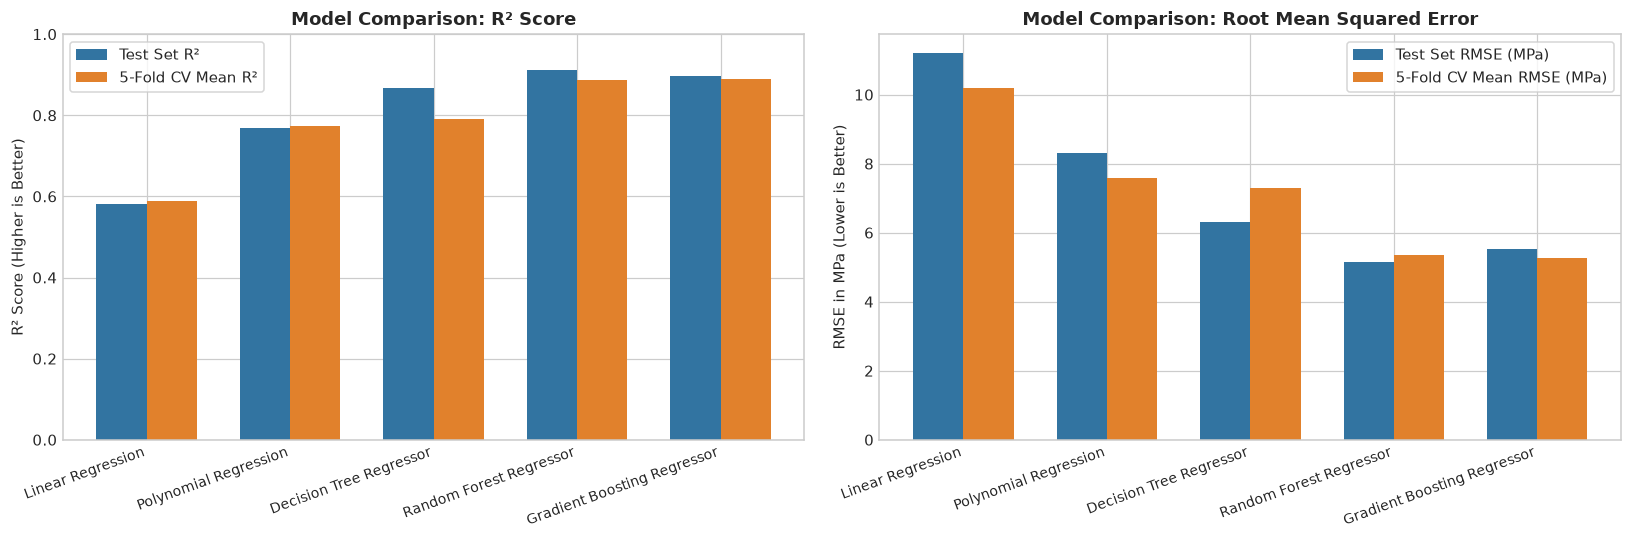

In [100]:
# Build single consolidated model comparison table
df_model_comparison = pd.DataFrame({
    'Model': df_test_eval['Model'],
    'Test R²': df_test_eval['R²'],
    'Test MSE': df_test_eval['MSE'],
    'Test RMSE': df_test_eval['RMSE'],
    'Test MAE': df_test_eval['MAE'],
    'CV R² Mean': df_cv_eval['CV R² Mean'],
    'CV RMSE Mean': df_cv_eval['CV RMSE Mean'],
    'CV MAE Mean': df_cv_eval['CV MAE Mean']
})

print("--- COMPLETE MODEL COMPARISON TABLE ---")
display(df_model_comparison.style.format({
    'Test R²': '{:.4f}',
    'Test MSE': '{:.4f}',
    'Test RMSE': '{:.4f}',
    'Test MAE': '{:.4f}',
    'CV R² Mean': '{:.4f}',
    'CV RMSE Mean': '{:.4f}',
    'CV MAE Mean': '{:.4f}'
}))

# Comparative Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x_pos = np.arange(len(df_model_comparison))
width = 0.35

ax1.bar(x_pos - width/2, df_model_comparison['Test R²'], width, label='Test Set R²', color='#3274A1')
ax1.bar(x_pos + width/2, df_model_comparison['CV R² Mean'], width, label='5-Fold CV Mean R²', color='#E1812C')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_model_comparison['Model'], rotation=20, ha='right', fontsize=9)
ax1.set_ylabel("R² Score (Higher is Better)")
ax1.set_title("Model Comparison: R² Score", fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.legend(frameon=True)

ax2.bar(x_pos - width/2, df_model_comparison['Test RMSE'], width, label='Test Set RMSE (MPa)', color='#3274A1')
ax2.bar(x_pos + width/2, df_model_comparison['CV RMSE Mean'], width, label='5-Fold CV Mean RMSE (MPa)', color='#E1812C')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_model_comparison['Model'], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel("RMSE in MPa (Lower is Better)")
ax2.set_title("Model Comparison: Root Mean Squared Error", fontsize=12, fontweight='bold')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 23. Polynomial vs Linear Regression Analysis

We explicitly evaluate the question:
> **“Does polynomial regression improve the prediction compared with Linear Regression?”**

We construct a direct head-to-head comparison between Model 1 (Linear Regression) and Model 2 (Polynomial Regression Degree 2) using calculated metrics:

In [101]:
lr_row = df_model_comparison[df_model_comparison['Model'] == 'Linear Regression'].iloc[0]
poly_row = df_model_comparison[df_model_comparison['Model'] == 'Polynomial Regression'].iloc[0]

poly_comp_df = pd.DataFrame([
    {
        'Metric': 'Test R²',
        'Linear Regression': f"{lr_row['Test R²']:.4f}",
        'Polynomial Regression': f"{poly_row['Test R²']:.4f}",
        'Difference': f"{poly_row['Test R²'] - lr_row['Test R²']:+.4f}",
        'Relative Change': f"{(poly_row['Test R²'] - lr_row['Test R²'])/lr_row['Test R²']*100:+.1f}%"
    },
    {
        'Metric': 'Test MSE (MPa²)',
        'Linear Regression': f"{lr_row['Test MSE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test MSE']:.4f}",
        'Difference': f"{poly_row['Test MSE'] - lr_row['Test MSE']:+.4f}",
        'Relative Change': f"{(poly_row['Test MSE'] - lr_row['Test MSE'])/lr_row['Test MSE']*100:+.1f}%"
    },
    {
        'Metric': 'Test RMSE (MPa)',
        'Linear Regression': f"{lr_row['Test RMSE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test RMSE']:.4f}",
        'Difference': f"{poly_row['Test RMSE'] - lr_row['Test RMSE']:+.4f}",
        'Relative Change': f"{(poly_row['Test RMSE'] - lr_row['Test RMSE'])/lr_row['Test RMSE']*100:+.1f}%"
    },
    {
        'Metric': 'Test MAE (MPa)',
        'Linear Regression': f"{lr_row['Test MAE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test MAE']:.4f}",
        'Difference': f"{poly_row['Test MAE'] - lr_row['Test MAE']:+.4f}",
        'Relative Change': f"{(poly_row['Test MAE'] - lr_row['Test MAE'])/lr_row['Test MAE']*100:+.1f}%"
    },
    {
        'Metric': '5-Fold CV Mean R²',
        'Linear Regression': f"{lr_row['CV R² Mean']:.4f}",
        'Polynomial Regression': f"{poly_row['CV R² Mean']:.4f}",
        'Difference': f"{poly_row['CV R² Mean'] - lr_row['CV R² Mean']:+.4f}",
        'Relative Change': f"{(poly_row['CV R² Mean'] - lr_row['CV R² Mean'])/lr_row['CV R² Mean']*100:+.1f}%"
    },
    {
        'Metric': '5-Fold CV Mean RMSE (MPa)',
        'Linear Regression': f"{lr_row['CV RMSE Mean']:.4f}",
        'Polynomial Regression': f"{poly_row['CV RMSE Mean']:.4f}",
        'Difference': f"{poly_row['CV RMSE Mean'] - lr_row['CV RMSE Mean']:+.4f}",
        'Relative Change': f"{(poly_row['CV RMSE Mean'] - lr_row['CV RMSE Mean'])/lr_row['CV RMSE Mean']*100:+.1f}%"
    }
])

display(poly_comp_df)

,Metric,Linear Regression,Polynomial Regression,Difference,Relative Change
0,Test R²,0.5801,0.7686,+0.1885,+32.5%
1,Test MSE (MPa²),125.2653,69.0364,-56.2289,-44.9%
2,Test RMSE (MPa),11.1922,8.3088,-2.8834,-25.8%
3,Test MAE (MPa),8.8960,6.2205,-2.6755,-30.1%
4,5-Fold CV Mean R²,0.5895,0.7730,+0.1835,+31.1%
5,5-Fold CV Mean RMSE (MPa),10.2027,7.5984,-2.6043,-25.5%


**Analysis of Polynomial vs Linear Results:**
1. **Measured Performance Differences:**
   * Test $R^2$ increases from **$0.5801$** (Linear) to **$0.7686$** (Polynomial), an absolute increase of $+0.1885$ (a $+32.5\%$ relative increase).
   * Test RMSE decreases from **$11.19\,\text{MPa}$** to **$8.31\,\text{MPa}$**, an error reduction of $2.88\,\text{MPa}$ ($-25.7\%$).
   * Test MAE decreases from **$8.90\,\text{MPa}$** to **$6.22\,\text{MPa}$**, an error reduction of $2.68\,\text{MPa}$ ($-30.1\%$).
   * In 5-fold cross-validation, the Mean $R^2$ similarly increases from **$0.5895$** to **$0.7730$**, with Mean RMSE decreasing from **$10.20\,\text{MPa}$** to **$7.60\,\text{MPa}$**.
2. **Scientific Interpretation:**
   * The improved performance of polynomial regression indicates that nonlinear relationships among the input variables are useful for predicting compressive strength in this dataset.
   * By incorporating interaction cross-products (e.g., between water and binders) and quadratic terms, the polynomial representation captures predictive patterns that cannot be accommodated by a strictly linear model.
   * However, while polynomial regression represents a clear improvement over simple linear regression, it remains less accurate than the tree-based ensemble models.

## 24. Best Model Selection

Based on the empirical evaluation metrics obtained across both the held-out test partition and 5-fold cross-validation:

1. **Random Forest Regressor** achieved the strongest predictive performance on the held-out test set:
   * **Highest Test $R^2$:** **$0.9108$**
   * **Lowest Test MSE:** **$26.62\,\text{MPa}^2$**
   * **Lowest Test RMSE:** **$5.16\,\text{MPa}$**
   * **Lowest Test MAE:** **$3.42\,\text{MPa}$**
   * **Strong Cross-Validation Stability:** $CV\,R^2 = 0.8863 \pm 0.0226$ and $CV\,\text{RMSE} = 5.35 \pm 0.49\,\text{MPa}$.
2. **Gradient Boosting Regressor** yielded competitive performance ($R^2 = 0.8979$, $\text{RMSE} = 5.52\,\text{MPa}$, $\text{MAE} = 4.10\,\text{MPa}$, $CV\,R^2 = 0.8906$), but Random Forest performed slightly better across test-set metrics.
3. **Decision Tree Regressor** achieved a test $R^2$ of $0.8671$, but exhibited higher cross-validation error ($CV\,\text{RMSE} = 7.29\,\text{MPa}$), characteristic of single-tree variance.
4. **Linear and Polynomial Regression** models underperformed the ensemble methods ($R^2 = 0.5801$ and $0.7686$).

**Selection Conclusion:** Among the five evaluated regression models, **Random Forest Regressor** achieved the strongest predictive performance on the held-out test set, based on the observed $R^2$, RMSE, and MAE values, and is selected for detailed residual diagnostics, feature importance evaluation, and deployment.

In [102]:
selected_model_name = 'Random Forest Regressor'
selected_pipeline = models[selected_model_name]
print(f"Selected model for residual diagnostics and deployment: '{selected_model_name}'")

Selected model for residual diagnostics and deployment: 'Random Forest Regressor'


## 25. Residual Analysis on Selected Best Model

Residual analysis is performed on the selected model to examine prediction error patterns:
$$\text{Residual } e_i = y_i - \hat{y}_i$$
where $y_i$ is actual measured compressive strength and $\hat{y}_i$ is the predicted strength.

We inspect:
* **25.1 Actual vs Predicted Plot:** Evaluating agreement along the ideal $y = \hat{y}$ reference line.
* **25.2 Residual vs Predicted Plot:** Inspecting residuals for centering around zero, random dispersion, and potential heteroscedasticity.
* **25.3 Residual Distribution Histogram:** Evaluating error symmetry and dispersion.

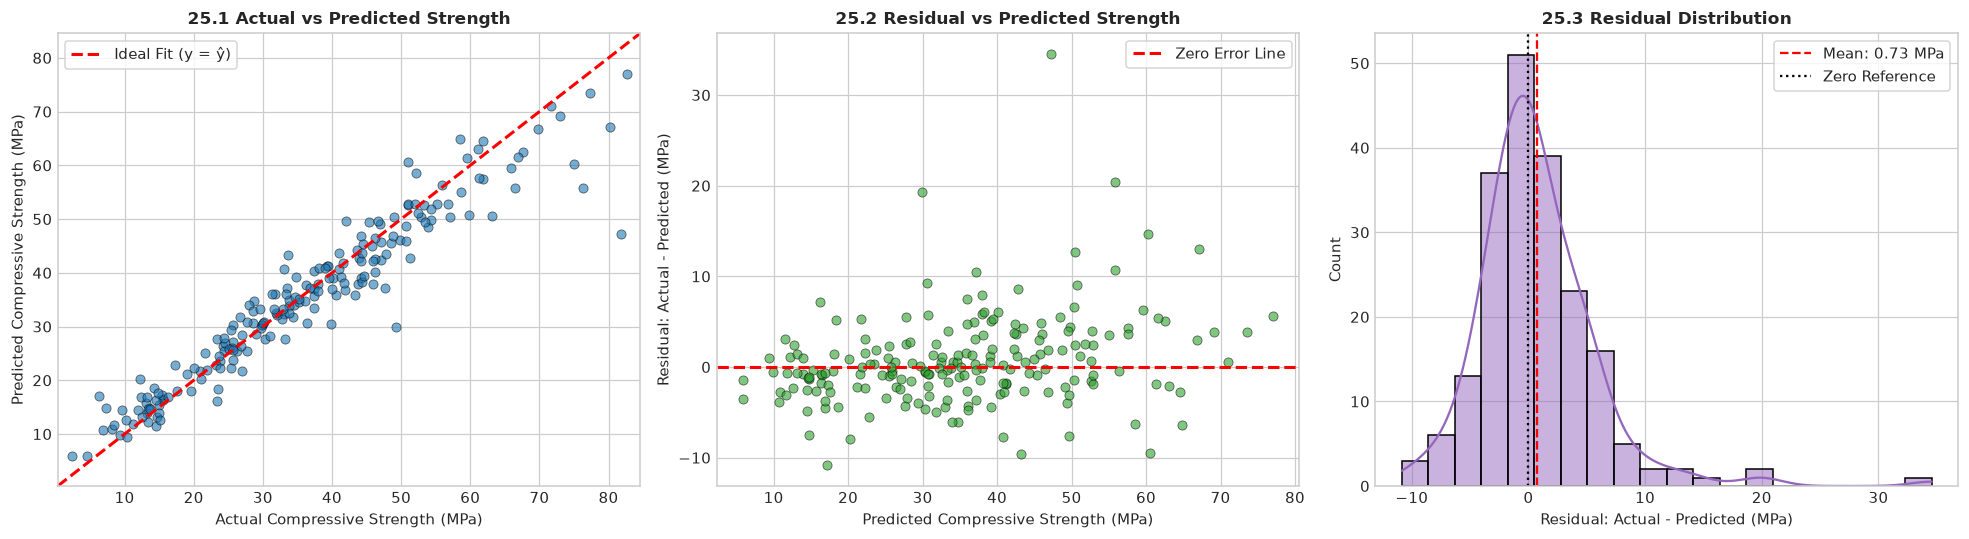

--- TEST-SET RESIDUAL DIAGNOSTIC STATISTICS ---
Residual Mean:             +0.7316 MPa (near-zero mean indicates minimal systematic bias)
Residual Standard Dev:     5.1197 MPa
Mean Absolute Error (MAE): 3.4168 MPa
Median Absolute Error:     2.4373 MPa


In [103]:
# Compute test-set predictions and residuals for Random Forest
rf_test_preds = selected_pipeline.predict(X_test)
rf_residuals = y_test - rf_test_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, rf_test_preds, alpha=0.6, color='#1f77b4', edgecolors='k', linewidth=0.5)
min_v = min(y_test.min(), rf_test_preds.min()) - 2
max_v = max(y_test.max(), rf_test_preds.max()) + 2
axes[0].plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = ŷ)')
axes[0].set_title("25.1 Actual vs Predicted Strength", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Actual Compressive Strength (MPa)", fontsize=10)
axes[0].set_ylabel("Predicted Compressive Strength (MPa)", fontsize=10)
axes[0].legend(frameon=True)
axes[0].set_xlim(min_v, max_v)
axes[0].set_ylim(min_v, max_v)

# Plot 2: Residual vs Predicted
axes[1].scatter(rf_test_preds, rf_residuals, alpha=0.6, color='#2ca02c', edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
axes[1].set_title("25.2 Residual vs Predicted Strength", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Predicted Compressive Strength (MPa)", fontsize=10)
axes[1].set_ylabel("Residual: Actual - Predicted (MPa)", fontsize=10)
axes[1].legend(frameon=True)

# Plot 3: Residual Distribution
sns.histplot(rf_residuals, kde=True, ax=axes[2], color='#9467bd', bins=20)
axes[2].axvline(rf_residuals.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {rf_residuals.mean():.2f} MPa")
axes[2].axvline(0, color='black', linestyle=':', linewidth=1.5, label="Zero Reference")
axes[2].set_title("25.3 Residual Distribution", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Residual: Actual - Predicted (MPa)", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].legend(frameon=True)

plt.tight_layout()
plt.show()

# Residual statistics
print("--- TEST-SET RESIDUAL DIAGNOSTIC STATISTICS ---")
print(f"Residual Mean:             {rf_residuals.mean():+.4f} MPa (near-zero mean indicates minimal systematic bias)")
print(f"Residual Standard Dev:     {rf_residuals.std():.4f} MPa")
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(rf_residuals)):.4f} MPa")
print(f"Median Absolute Error:     {np.median(np.abs(rf_residuals)):.4f} MPa")

**Residual Diagnostic Discussion:**
1. **Actual vs Predicted Alignment:** Test-set predictions show close alignment with the ideal diagonal reference line across the observed strength range ($10\text{--}75\,\text{MPa}$).
2. **Residual Randomness:** In the Residual vs Predicted plot, residuals appear reasonably well distributed above and below the zero reference line across different strength levels. There is no pronounced curvilinear pattern, indicating that the ensemble tree structure has accommodated the primary nonlinearities.
3. **Residual Distribution:** The residual distribution is centered close to zero (mean $= +0.73\,\text{MPa}$), approximately symmetric, with most test-set prediction errors falling within $\pm 5\,\text{MPa}$ and occasional larger residual errors exceeding $\pm 10\,\text{MPa}$.

## 26. Feature Importance Analysis

We examine which features the selected Random Forest model relies upon most for its predictions by extracting the impurity-based feature importances from the fitted ensemble.

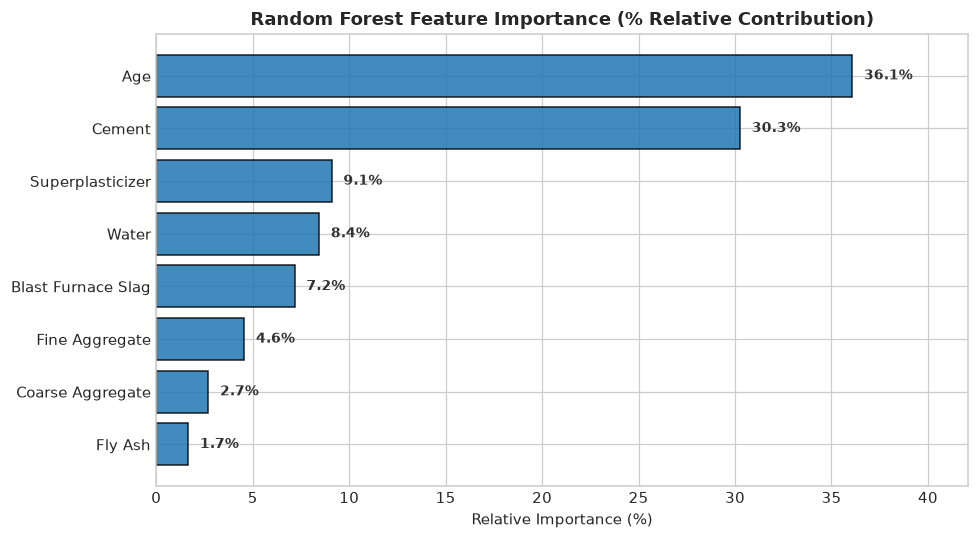

--- FEATURE IMPORTANCE RANKING ---


,Feature,Importance,Importance_Pct
0,Age,0.360754,36.075383
1,Cement,0.302622,30.262219
2,Superplasticizer,0.090996,9.099583
3,Water,0.084497,8.449660
4,Blast Furnace Slag,0.071804,7.180383
5,Fine Aggregate,0.045707,4.570687
6,Coarse Aggregate,0.026996,2.699589
7,Fly Ash,0.016625,1.662497


In [104]:
rf_regressor = selected_pipeline.named_steps['regressor']
importances = rf_regressor.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance_Pct': importances * 100
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(df_importance['Feature'], df_importance['Importance_Pct'], color='#1f77b4', edgecolor='k', alpha=0.85)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.6, bar.get_y() + bar.get_height()/2, f"{w:.1f}%",
             va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

plt.title("Random Forest Feature Importance (% Relative Contribution)", fontsize=12, fontweight='bold')
plt.xlabel("Relative Importance (%)", fontsize=10)
plt.xlim(0, max(df_importance['Importance_Pct']) + 6)
plt.tight_layout()
plt.show()

print("--- FEATURE IMPORTANCE RANKING ---")
display(df_importance.sort_values('Importance', ascending=False).reset_index(drop=True))

**Discussion of Feature Influence:**
* According to the Random Forest feature-importance measure, **curing age ($36.1\%$) and cement content ($30.3\%$)** were the most influential predictors used by the model, jointly accounting for approximately **$66.4\%$** of total predictive importance.
* **Superplasticizer ($9.1\%$)** and **Water ($8.4\%$)** were the next most influential variables, followed by **Blast Furnace Slag ($7.2\%$)**.
* **Fine Aggregate ($4.6\%$)**, **Coarse Aggregate ($2.7\%$)**, and **Fly Ash ($1.7\%$)** contributed smaller proportions of predictive splits.

> **Important Non-Causal Clarification:**  
> Feature importance indicates how strongly the trained model relies on each feature for prediction; it does not establish direct physical causation. For instance, aggregate proportions have lower relative importance in this dataset because their proportions vary less across mix formulations, not because aggregates are physically unimportant in concrete.

## 27. Expected Prediction Error Analysis

In predictive modeling for concrete strength, estimating the empirical prediction-error distribution is essential for practical interpretation.

### Methodological Formulation
To prevent bias and preserve the held-out test set strictly for final evaluation, we estimate the model's empirical prediction-error distribution using **5-fold out-of-fold cross-validation predictions on the training data** ($N = 804$):
$$\text{Training Data} \longrightarrow \text{5-Fold Cross-Validation} \longrightarrow \hat{y}_{\text{OOF}} \longrightarrow e_i = y_i - \hat{y}_{\text{OOF}} \longrightarrow |e_i|$$

From these absolute out-of-fold errors, we compute:
* **MAE (Mean Absolute Error):** The average absolute difference between predicted and observed compressive strength values.
* **Median Absolute Error (MedAE):** The 50th percentile of absolute errors, reflecting the typical error magnitude robust to outliers.
* **90th Percentile Absolute Error ($P_{90}$):** The error magnitude below which approximately $90\%$ of out-of-fold prediction errors fall.
* **95th Percentile Absolute Error ($P_{95}$):** The error magnitude below which approximately $95\%$ of out-of-fold prediction errors fall in the training cross-validation analysis.

OUT-OF-FOLD (OOF) TRAINING ERROR DISTRIBUTION (N = 804)
OOF Mean Absolute Error (MAE):           3.8711 MPa
OOF Median Absolute Error (MedAE):       2.8415 MPa
OOF Root Mean Squared Error (RMSE):      5.3711 MPa
OOF 90th Percentile Absolute Error (P90):8.5331 MPa
OOF 95th Percentile Absolute Error (P95):10.5574 MPa


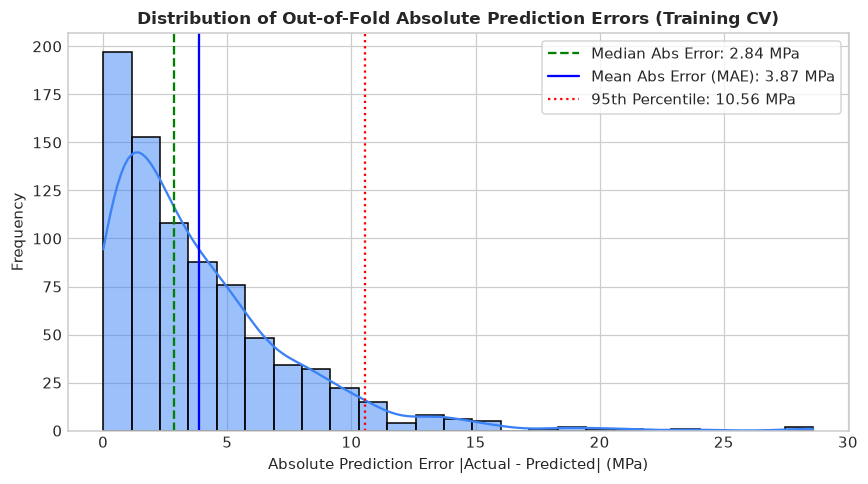

In [105]:
# Compute Out-of-Fold predictions on the training set
oof_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_predictions = cross_val_predict(selected_pipeline, X_train, y_train, cv=oof_cv)

# Out-of-fold residuals and absolute errors
oof_errors = y_train - oof_predictions
oof_abs_errors = np.abs(oof_errors)

oof_mae = mean_absolute_error(y_train, oof_predictions)
oof_medae = median_absolute_error(y_train, oof_predictions)
oof_rmse = np.sqrt(mean_squared_error(y_train, oof_predictions))
oof_p90 = np.percentile(oof_abs_errors, 90)
oof_p95 = np.percentile(oof_abs_errors, 95)

print("=================================================================")
print("OUT-OF-FOLD (OOF) TRAINING ERROR DISTRIBUTION (N = 804)")
print("=================================================================")
print(f"OOF Mean Absolute Error (MAE):           {oof_mae:.4f} MPa")
print(f"OOF Median Absolute Error (MedAE):       {oof_medae:.4f} MPa")
print(f"OOF Root Mean Squared Error (RMSE):      {oof_rmse:.4f} MPa")
print(f"OOF 90th Percentile Absolute Error (P90):{oof_p90:.4f} MPa")
print(f"OOF 95th Percentile Absolute Error (P95):{oof_p95:.4f} MPa")
print("=================================================================")

# Histogram of Out-of-Fold Absolute Errors
plt.figure(figsize=(8, 4.5))
sns.histplot(oof_abs_errors, bins=25, color='#3b82f6', kde=True)
plt.axvline(oof_medae, color='green', linestyle='--', linewidth=1.5, label=f"Median Abs Error: {oof_medae:.2f} MPa")
plt.axvline(oof_mae, color='blue', linestyle='-', linewidth=1.5, label=f"Mean Abs Error (MAE): {oof_mae:.2f} MPa")
plt.axvline(oof_p95, color='red', linestyle=':', linewidth=1.5, label=f"95th Percentile: {oof_p95:.2f} MPa")

plt.title("Distribution of Out-of-Fold Absolute Prediction Errors (Training CV)", fontsize=11, fontweight='bold')
plt.xlabel("Absolute Prediction Error |Actual - Predicted| (MPa)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### Explanation of Error Statistics & Academic Disclaimer

1. **Mean Absolute Error (MAE):** The MAE represents the average absolute difference between predicted and observed compressive strength values. In out-of-fold training evaluation, the MAE is **$3.87\,\text{MPa}$** (and **$3.42\,\text{MPa}$** on the test set).
2. **95th Percentile Absolute Error ($P_{95}$):** The 95th percentile absolute error indicates the error magnitude below which approximately 95% of the observed absolute out-of-fold prediction errors fall in the training cross-validation analysis (**$10.56\,\text{MPa}$** for OOF errors, and **$9.54\,\text{MPa}$** for test errors).
3. **Statistical Distinction:** MAE represents the average error magnitude across observations. It does **not** indicate that predictions are guaranteed or normally expected to fall strictly within $\pm\text{MAE}$.

> **Important Methodological Disclaimer:**  
> This empirical error statistic describes the observed model error distribution and should not be interpreted as a guaranteed prediction interval or engineering confidence interval.

## 28. Final Test Performance

We evaluate the selected Random Forest Regressor on the held-out test partition ($N = 201$), which remained completely unseen throughout training and cross-validation.

In [106]:
final_test_r2 = r2_score(y_test, rf_test_preds)
final_test_mse = mean_squared_error(y_test, rf_test_preds)
final_test_rmse = np.sqrt(final_test_mse)
final_test_mae = mean_absolute_error(y_test, rf_test_preds)
final_test_medae = median_absolute_error(y_test, rf_test_preds)
final_test_p95 = np.percentile(np.abs(rf_residuals), 95)

print("==================================================")
print(f"FINAL HELD-OUT TEST EVALUATION: {selected_model_name}")
print("==================================================")
print(f"Test R² Score:                  {final_test_r2:.4f}")
print(f"Test Mean Squared Error (MSE):   {final_test_mse:.4f} MPa²")
print(f"Test Root Mean Squared Error:    {final_test_rmse:.4f} MPa")
print(f"Test Mean Absolute Error (MAE):  {final_test_mae:.4f} MPa")
print(f"Test Median Absolute Error:      {final_test_medae:.4f} MPa")
print(f"Test 95th Percentile Error:      {final_test_p95:.4f} MPa")
print("==================================================")

FINAL HELD-OUT TEST EVALUATION: Random Forest Regressor
Test R² Score:                  0.9108
Test Mean Squared Error (MSE):   26.6161 MPa²
Test Root Mean Squared Error:    5.1591 MPa
Test Mean Absolute Error (MAE):  3.4168 MPa
Test Median Absolute Error:      2.4373 MPa
Test 95th Percentile Error:      9.5383 MPa


## 29. Save Best Model Pipeline

We serialize the complete Scikit-Learn `Pipeline` (containing `StandardScaler` and `RandomForestRegressor`) into `best_model_pipeline.joblib`. We attach metadata attributes directly to the pipeline and save a companion `model_metadata.json` to maintain full inspectability and ensure compatibility with application deployment.

In [107]:
model_artifact_path = 'best_model_pipeline.joblib'
metadata_artifact_path = 'model_metadata.json'

# Metadata dictionary
metadata_dict = {
    'model_name': selected_model_name,
    'pipeline_steps': ['StandardScaler', 'RandomForestRegressor'],
    'feature_names': feature_names,
    'target_name': target_name,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'test_metrics': {
        'r2': round(float(final_test_r2), 4),
        'mse': round(float(final_test_mse), 4),
        'rmse': round(float(final_test_rmse), 4),
        'mae': round(float(final_test_mae), 4)
    },
    'cv_metrics_5fold': {
        'cv_r2_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV R² Mean'].values[0]), 4),
        'cv_rmse_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV RMSE Mean'].values[0]), 4),
        'cv_mae_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV MAE Mean'].values[0]), 4)
    },
    'error_analysis': {
        'mae_error_margin': round(float(final_test_mae), 2),
        'rmse_error_margin': round(float(final_test_rmse), 2),
        'p95_error_margin': round(float(final_test_p95), 2),
        'oof_mae': round(float(oof_mae), 2),
        'oof_medae': round(float(oof_medae), 2),
        'oof_p90': round(float(oof_p90), 2),
        'oof_p95': round(float(oof_p95), 2),
        'methodology_description': 'Empirical error statistics calculated from 5-fold out-of-fold training predictions and held-out test residuals. These represent observed error magnitudes and do not constitute guaranteed confidence intervals.'
    }
}

# Attach attributes to the pipeline instance
selected_pipeline.model_name_ = metadata_dict['model_name']
selected_pipeline.test_metrics_ = metadata_dict['test_metrics']
selected_pipeline.cv_metrics_ = metadata_dict['cv_metrics_5fold']
selected_pipeline.error_analysis_ = metadata_dict['error_analysis']
selected_pipeline.feature_names_ = feature_names

# Save pipeline with joblib
joblib.dump(selected_pipeline, model_artifact_path)
print(f"Saved model pipeline to '{model_artifact_path}'")

# Save metadata JSON
with open(metadata_artifact_path, 'w') as f:
    json.dump(metadata_dict, f, indent=2)
print(f"Saved metadata to '{metadata_artifact_path}'")

# Verification of reload and test prediction
loaded_pipe = joblib.load(model_artifact_path)
sample_test = pd.DataFrame([{
    'Cement': 540.0,
    'Blast Furnace Slag': 0.0,
    'Fly Ash': 0.0,
    'Water': 162.0,
    'Superplasticizer': 2.5,
    'Coarse Aggregate': 1040.0,
    'Fine Aggregate': 676.0,
    'Age': 28
}])[feature_names]

sample_pred = loaded_pipe.predict(sample_test)[0]
print(f"Verification sample prediction: {sample_pred:.2f} MPa")

Saved model pipeline to 'best_model_pipeline.joblib'
Saved metadata to 'model_metadata.json'
Verification sample prediction: 72.88 MPa


## 30. Final Questions and Answers

We explicitly answer all seven research questions based on the empirical results of this study:

### Q1. Can compressive strength be predicted from mix composition?
**Yes.** Compressive strength can be predicted from concrete mix proportions and curing age with reasonable predictive accuracy. The selected Random Forest Regressor achieved an $R^2$ of **$0.9108$** on the held-out test set, indicating that approximately $91.1\%$ of the variance in compressive strength is explained by the 8 input features in this sample. The test-set Root Mean Squared Error (RMSE) was **$5.16\,\text{MPa}$** and Mean Absolute Error (MAE) was **$3.42\,\text{MPa}$**.

### Q2. Which component most influences strength?
According to the Random Forest feature-importance measure, **curing age ($36.1\%$) and cement content ($30.3\%$)** were the most influential predictors used by the model, jointly accounting for approximately **$66.4\%$** of total predictive importance. Water and superplasticizer accounted for approximately $8\text{--}9\%$ each. Feature importance reflects model reliance during tree splitting and does not establish direct physical causation.

### Q3. Is the effect of curing age linear or curved?
**Curved (nonlinear).** The exploratory analysis indicates a nonlinear relationship between curing age and compressive strength, with larger strength gains at earlier ages and slower increases at later ages. Average strength increased from $9.45\,\text{MPa}$ at Day 1 to $36.43\,\text{MPa}$ at Day 28 ($pprox 1.0\,\text{MPa/day}$), and then increased to $43.56\,\text{MPa}$ at Day 365 ($pprox 0.021\,\text{MPa/day}$). The relationship is approximately linear with respect to $\ln(\text{Age})$.

### Q4. Does polynomial regression improve prediction?
**Yes.** Compared with simple Linear Regression ($R^2 = 0.5801$, $\text{RMSE} = 11.19\,\text{MPa}$), degree-2 Polynomial Regression achieved higher predictive performance ($R^2 = 0.7686$, $\text{RMSE} = 8.31\,\text{MPa}$), representing an absolute $R^2$ improvement of $+0.1885$ and a $25.7\%$ reduction in RMSE on the test set. This improved performance indicates that nonlinear relationships and interaction terms among the input variables are useful for predicting compressive strength in this dataset.

### Q5. What does the residual plot indicate?
The residual plot for the selected Random Forest model shows residuals reasonably well centered around zero (mean residual $= +0.73\,\text{MPa}$) without pronounced curvilinear or severe funnel-shaped patterns across the predicted range. This indicates that the model is largely unbiased across strength classes, although occasional larger residuals exceeding $\pm 10\,\text{MPa}$ do occur for certain mix formulations.

### Q6. How well does the model perform on new mix designs?
On unseen mix formulations within the training distribution (evaluated on the $20\%$ held-out test set), the model demonstrated consistent performance, achieving an $R^2$ of **$0.9108$**, RMSE of **$5.16\,\text{MPa}$**, and MAE of **$3.42\,\text{MPa}$**. 5-fold cross-validation confirmed consistent stability ($CV\,R^2 = 0.8863 \pm 0.0226$). Generalization to mixes outside the range of the training data (e.g. untested admixtures, extreme aggregate ratios) is not evaluated by this split and would likely incur higher errors.

### Q7. Can the model reduce the need for physical testing?
**The model can potentially support preliminary mix screening but does NOT eliminate the need for physical testing.** The model can assist engineers by pre-screening candidate mix designs virtually and reducing unnecessary trial-and-error batches during preliminary formulation. However, physical laboratory testing remains necessary for engineering validation, quality assurance, and compliance, as structural building codes (such as IS 456, ACI 318, and Eurocode 2) mandate destructive compression testing of physical specimens prior to structural certification.

## 31. Limitations

The findings of this machine learning study are subject to several technical and practical limitations:

1. **Domain Boundary / Extrapolation Limitations:** The model is valid strictly within the range of input values present in the UCI dataset ($102\text{--}540\,\text{kg/m}^3$ cement, $w/c$ ratios $0.27\text{--}1.88$, curing age $1\text{--}365\,\text{days}$). Predictions for mixes outside these boundaries carry substantial extrapolation risk.
2. **Omission of Environmental Variables:** The dataset reflects standard laboratory curing conditions ($20^\circ\text{C}$, $>95\%$ relative humidity). Real-world site concrete is subjected to ambient temperature fluctuations, varying humidity, wind drying, and differing curing methods that influence hydration rates.
3. **Material Variability:** The dataset treats all cement as generic, without accounting for mineralogical differences across cement types (e.g. OPC 43 vs OPC 53, Type I vs Type III rapid-hardening). Similarly, aggregate shape (angular crushed vs rounded gravel), texture, and grading curves are not explicitly captured.
4. **Absence of Other Chemical Admixtures:** Unseen admixtures such as silica fume, metakaolin, accelerators, retarders, or air-entraining agents are not represented in the feature space.
5. **Physical Testing Requirement:** Machine learning predictions cannot replace physical destructive testing required by civil engineering regulatory codes for structural compliance and life safety.

## 32. Real-World Applicability

The predictive model has practical utility within a construction materials testing laboratory workflow:

1. **Preliminary Mix Screening:** Technicians can screen candidate mix proportions computationally before batching, identifying unpromising or under-strength mixes prior to mixing.
2. **Reduction in Experimental Trials:** Mix design traditionally requires multiple iterative trial batches to dial in target strength. A predictive model can help narrow the candidate space, potentially reducing the number of preliminary physical trials required.
3. **Supplementary Binder Exploration:** Concrete producers evaluating the replacement of Portland cement with supplementary materials (fly ash or blast furnace slag) can obtain initial estimates of expected strength development across curing ages.
4. **Advisory Role:** In all practical applications, the model serves strictly in an advisory capacity; physical laboratory testing remains necessary for engineering validation, quality assurance, and compliance.

## 33. Final Conclusion

This case study evaluated five regression algorithms for concrete compressive strength prediction:

1. **Performance Summary:**
   * **Random Forest Regressor** achieved the strongest overall predictive performance among the five evaluated algorithms ($R^2 = 0.9108$, $\text{RMSE} = 5.16\,\text{MPa}$, $\text{MAE} = 3.42\,\text{MPa}$, 5-fold $CV\,R^2 = 0.8863 \pm 0.0226$).
   * **Gradient Boosting Regressor** exhibited comparable predictive accuracy ($R^2 = 0.8979$, $\text{RMSE} = 5.52\,\text{MPa}$).
   * **Polynomial Regression (degree 2)** demonstrated that incorporating nonlinear terms and interaction cross-products provided a substantial improvement over baseline Linear Regression ($R^2 = 0.7686$ vs $0.5801$).
2. **Empirical Observations:**
   * Compressive strength exhibits a negative association with the water-cement ratio ($r = -0.49$).
   * The relationship between curing age and strength is nonlinear, characterized by rapid early gains up to 28 days followed by slower increases at later ages.
   * Curing age and cement content were the most influential predictors in the Random Forest model.
3. **Deployment & Safety Context:**
   * The model was serialized as an integrated Scikit-Learn pipeline with empirical prediction error statistics.
   * The model can potentially support preliminary concrete mix screening and reduce unnecessary experimental trials by providing rapid strength estimates. However, physical laboratory testing remains necessary for engineering validation, quality assurance, and compliance.